In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm



warnings.filterwarnings("ignore")

In [2]:
def make_train_test_split(ts_series, horizon=24, season_m=24, plot=True):
    """
    Performs the train/test split of the time series, validates the minimum amount
    of seasonal cycles, and visually plots the data cut-off line.
    """
    test_steps = horizon
    min_train  = season_m * 6
    
    if len(ts_series) < test_steps + min_train:
        raise ValueError(
            f"Insufficient data: {len(ts_series)} hours available, but at least "
            f"{test_steps + min_train} hours are required."
        )
    
    train_data = ts_series.iloc[:-test_steps]
    test_data  = ts_series.iloc[-test_steps:]
    
    print(f" Train: {len(train_data)} hours ({train_data.index[0].strftime('%Y-%m-%d')} → {train_data.index[-1].strftime('%Y-%m-%d %H:%M')})")
    print(f" Test : {len(test_data)} hours ({test_data.index[0].strftime('%Y-%m-%d %H:%M')} → {test_data.index[-1].strftime('%Y-%m-%d %H:%M')})")
    
    if plot:
        fig, ax = plt.subplots(figsize=(13, 4))
        
        # Displays the last 14 days of training to provide context + the test day (24h)
        context_days = 14
        train_tail = train_data.iloc[-horizon * context_days:]
        
        ax.plot(train_tail.index, train_tail.values, label=f"Train (last {context_days} days)", color="#1f77b4", lw=1.1)
        ax.plot(test_data.index, test_data.values, label=f"Test ({horizon}h / 1 day)", color="#d62728", lw=1.8)
        
        # Vertical line indicating the exact moment of the split
        ax.axvline(x=test_data.index[0], color="black", linestyle="--", alpha=0.8, label="Cut-off Line (Split)")
        
        stop_title = ts_series.name if hasattr(ts_series, 'name') else ''
        ax.set_title(f"Train / Test Split — Point {stop_title}", fontsize=12, fontweight="bold")
        ax.set_ylabel("Boardings / hour")
        ax.set_xlabel("Date / Time")
        ax.legend(loc="upper left")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    return train_data, test_data


In [3]:
def check_stationarity(data, alpha=0.05):
    series = data.dropna()
    
    adf_stat, adf_p, *_ = adfuller(series)
    adf_res = "Stationary" if adf_p < alpha else "Non-Stationary"
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    kpss_res = "Stationary" if kpss_p > alpha else "Non-Stationary"
    
    df = pd.DataFrame([
        {"Test": "ADF", "Statistic": f"{adf_stat:.4f}", "p-value": f"{adf_p:.4f}", "Result": adf_res},
        {"Test": "KPSS", "Statistic": f"{kpss_stat:.4f}", "p-value": f"{kpss_p:.4f}", "Result": kpss_res}
    ])
    
    display(df)
    
    if adf_p < alpha and kpss_p > alpha:
        print("Verdict: Stationary Series")
    else:
        print("Verdict: Non-Stationary Series")


In [4]:
def plot_acf_pacf(series, stop_id, max_lags=72, output_dir=None):
    lags = min(max_lags, len(series) // 2 - 1)
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 6))
    plot_acf(series, lags=lags, ax=axes[0], title=f"ACF - Stop {stop_id}")
    plot_pacf(series, lags=lags, ax=axes[1], title="PACF", method="ywm")
    
    axes[0].grid(alpha=0.3)
    axes[1].grid(alpha=0.3)
    fig.tight_layout()
    
    if output_dir:
        fig.savefig(output_dir / "acf_pacf.png", dpi=150)
        
    plt.show()

In [5]:
def select_sarima_order(series, X=None, season_m=24, trace=True):
    """
    Uses auto_arima to find the optimal SARIMA parameters for the given time series.
    Returns the best (p,d,q) and (P,D,Q,m) orders based on the chosen information criterion.
    """
    try:
        print("Running auto_arima to find the best model parameters...")
        auto = pm.auto_arima(
            series,
            X=X,
            seasonal=True,
            m=season_m,
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore",
            information_criterion="aic", # optimization metric
            max_p=3, max_q=3, max_P=2, max_Q=2,
            d=None, D=None,
            trace=trace,
        )
        order = auto.order
        seasonal_order = auto.seasonal_order
        print(f"\nBest model found: SARIMA{order}x{seasonal_order}")
        
        return order, seasonal_order
        
    except ImportError:
        print(f"\nWarning: 'pmdarima' is not installed. Using default parameters: SARIMA(1,0,1)(1,1,1)[{season_m}]")
        return (1, 0, 1), (1, 1, 1, season_m)


In [6]:
def fit_sarima_model(series, order, seasonal_order, X=None, show_summary=True):
    print(f"Fitting SARIMAX{order}x{seasonal_order} model...")
    model = SARIMAX(
        series,
        exog=X,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fitted_model = model.fit(disp=False)
    
    if show_summary:
        print(fitted_model.summary())
        
    return fitted_model


In [7]:
def predict_and_evaluate(fit_model, test_data, X_test=None, train_data=None, stop_id=None, output_dir=None):
    steps = len(test_data)
    forecast_res = fit_model.get_forecast(steps=steps, exog=X_test)
    
    fc_mean = forecast_res.predicted_mean
    fc_ci   = forecast_res.conf_int(alpha=0.05)
    fc_mean.index = test_data.index
    fc_ci.index   = test_data.index
    
    mae  = mean_absolute_error(test_data, fc_mean)
    rmse = np.sqrt(mean_squared_error(test_data, fc_mean))
    
    mask = test_data.values != 0
    mape_val = np.mean(np.abs((test_data.values[mask] - fc_mean.values[mask]) / test_data.values[mask])) * 100
    wape_val = (np.sum(np.abs(test_data.values - fc_mean.values)) / np.sum(np.abs(test_data.values))) * 100
    
    print(f"  MAE  : {mae:.3f}")
    print(f"  RMSE : {rmse:.3f}")
    print(f"  MAPE : {mape_val:.2f}%")
    print(f"  WAPE : {wape_val:.2f}%")
    
    # Grafico de Previsao vs Real
    fig, ax = plt.subplots(figsize=(13, 4.5))
    
    if train_data is not None:
        train_tail = train_data.iloc[-steps * 7:]
        ax.plot(train_tail.index, train_tail.values, color="steelblue", lw=1.0, label="Treino (ultimos 7 dias)")
        
    ax.plot(test_data.index, test_data.values, color="black", lw=1.2, label="Real (Teste)")
    ax.plot(fc_mean.index, fc_mean.values, color="crimson", lw=1.5, ls="--", label="Previsao SARIMA")
    ax.fill_between(fc_ci.index, fc_ci.iloc[:, 0], fc_ci.iloc[:, 1], color="crimson", alpha=0.15, label="IC 95%")
    
    ax.set_title(f"Previsao SARIMA - Ponto {stop_id} | MAE={mae:.1f} | RMSE={rmse:.1f} | WAPE={wape_val:.1f}%")
    ax.set_ylabel("Embarques / hora")
    ax.set_xlabel("Data / Hora")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    
    if output_dir:
        fig.savefig(output_dir / "sarima_forecast.png", dpi=150)
        
    plt.show()
    
    return fc_mean, fc_ci


In [8]:
def plot_sarima_forecast(train_series, test_series, fc_mean, fc_ci, stop_id, order, seasonal_order, mae, rmse, mape_val, output_dir=None):
    """
    Plots the SARIMA forecast against the actual test data, including 
    confidence intervals and a portion of the training data for context.
    """
    fig, ax = plt.subplots(figsize=(13, 4.5))
    
    # Displays the last 7 days of training for context
    horizon = len(test_series)
    train_tail = train_series.iloc[-horizon * 7:]
    
    ax.plot(train_tail.index, train_tail.values, color="steelblue", lw=1.0, label="Train (last 7 days)")
    ax.plot(test_series.index, test_series.values, color="black", lw=1.2, label="Actual (Test)")
    ax.plot(fc_mean.index, fc_mean.values, color="crimson", lw=1.5, linestyle="--", label="SARIMA Forecast")
    
    ax.fill_between(
        fc_ci.index,
        fc_ci.iloc[:, 0],
        fc_ci.iloc[:, 1],
        color="crimson",
        alpha=0.15,
        label="95% Confidence Interval",
    )
    
    ax.axvline(x=test_series.index[0], color="gray", linestyle=":", alpha=0.8, label="Forecast Start")
    
    ax.set_title(
        f"SARIMA{order}x{seasonal_order} | Point {stop_id} | "
        f"MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape_val:.1f}%",
        fontsize=11,
    )
    ax.set_ylabel("Boardings / hour")
    ax.set_xlabel("Date / Time")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    
    if output_dir:
        fig.savefig(output_dir / "sarima_forecast.png", dpi=150)
        
    plt.show()


In [9]:

OUTPUT_DIR = Path("outputs/sarima")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_FILE  = Path("data/sunt.data")

# Hourly data with daily seasonality M=24. Weekly M=168 is intractable for SARIMA.
FREQ         = "1h"       # hourly boardings per stop
SEASON_M     = 24         # daily seasonality
HORIZON      = 24         # test horizon — 1 day ahead (same as LSTM/GRU/Transformer/Chronos)
STOP_ID      = None       # None = busiest stop
START_DATE   = "2024-04-01"
PERIODS      = 60         # calendar days to load (2024-04-01 → 2024-05-30)

In [10]:
print("Loading cached data ...")
with open(DATA_FILE, "rb") as _f:
    ts_all = pickle.load(_f)["ts"].iloc[:, :20]

if STOP_ID is None:
    STOP_ID = ts_all.sum().idxmax()
print(f"Selected stop: {STOP_ID}")

series = ts_all[STOP_ID].asfreq(FREQ).fillna(0).astype(float)
print(f"Series length: {len(series)} hours  ({series.index[0].date()} → {series.index[-1].date()})")

Loading cached data ...
Selected stop: 44042532
Series length: 1440 hours  (2024-04-01 → 2024-05-30)


Features exogenas criadas (Primeiras 5 linhas):


,is_rush_hour,dia_1,dia_2,dia_3,dia_4,dia_5,dia_6
2024-04-01 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-04-01 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-04-01 02:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-04-01 03:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-04-01 04:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0


 Train: 1416 hours (2024-04-01 → 2024-05-29 23:00)
 Test : 24 hours (2024-05-30 00:00 → 2024-05-30 23:00)


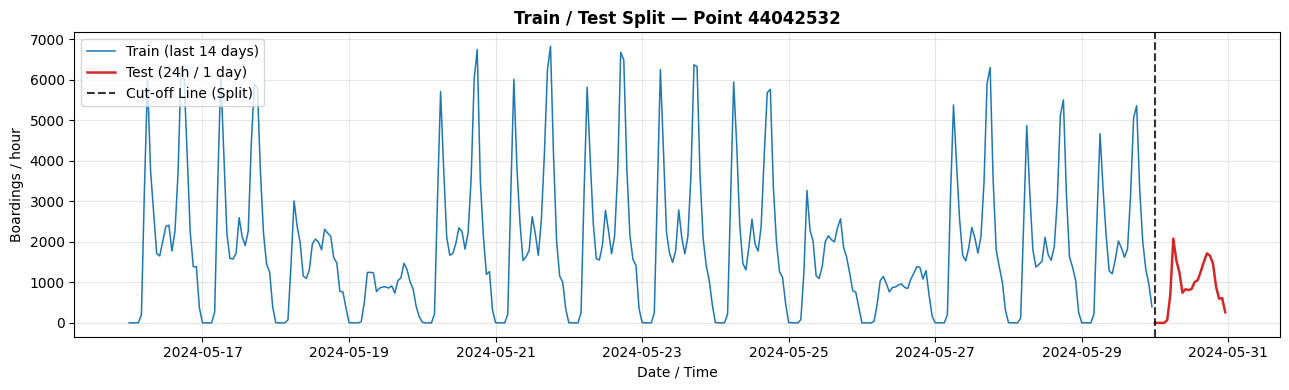

In [ ]:

X = pd.DataFrame(index=series.index)

dia_da_semana = X.index.dayofweek
X_dias = pd.get_dummies(dia_da_semana, prefix='dia', drop_first=True)
X_dias = X_dias.set_index(X.index).astype(float)

hora = X.index.hour
X['is_rush_hour'] = ((hora >= 7) & (hora <= 9)) | ((hora >= 17) & (hora <= 19))
X['is_rush_hour'] = X['is_rush_hour'].astype(float)

X = pd.concat([X, X_dias], axis=1)

print("Features exogenas criadas (Primeiras 5 linhas):")
display(X.head())

train, test = make_train_test_split(series, horizon=HORIZON, season_m=SEASON_M, plot=True)

X_train = X.iloc[:-HORIZON]
X_test  = X.iloc[-HORIZON:]


In [12]:
check_stationarity(train)

,Test,Statistic,p-value,Result
0,ADF,-4.6269,0.0001,Stationary
1,KPSS,0.0539,0.1000,Stationary


Verdict: Stationary Series


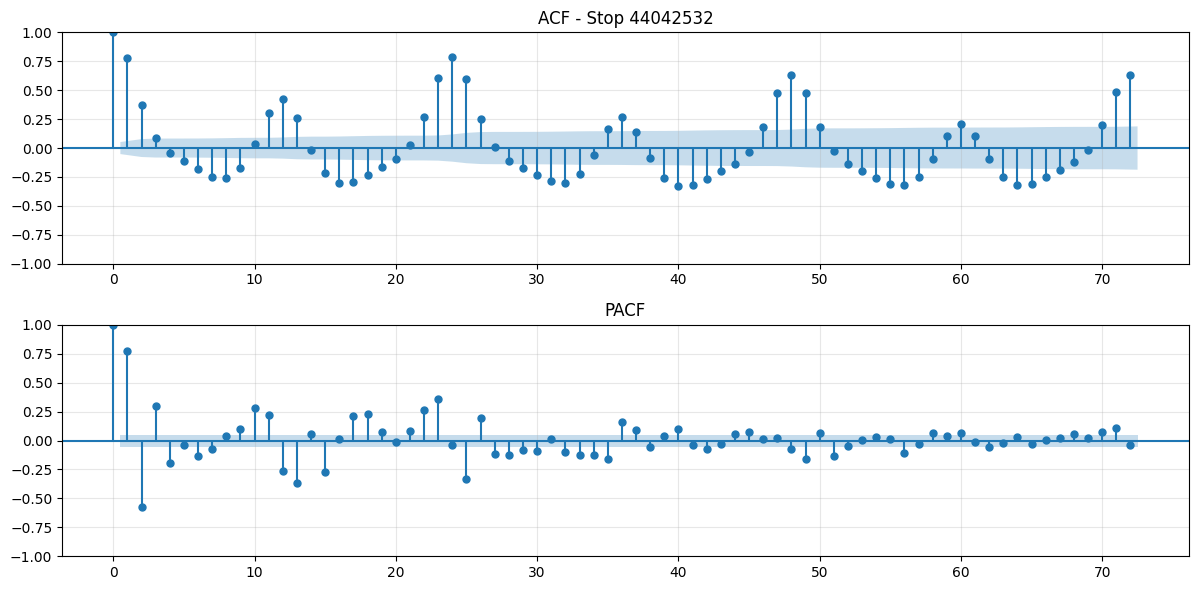

In [13]:
plot_acf_pacf(train, STOP_ID, max_lags=72, output_dir=OUTPUT_DIR)

In [14]:
order, seasonal_order = select_sarima_order(train, X=X_train, season_m=SEASON_M, trace=True)

Running auto_arima to find the best model parameters...
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=inf, Time=11.76 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=24573.755, Time=0.06 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=inf, Time=5.09 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=23146.922, Time=4.02 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=24871.346, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[24] intercept   : AIC=24240.476, Time=0.05 sec
 ARIMA(0,0,1)(1,0,1)[24] intercept   : AIC=inf, Time=5.14 sec
 ARIMA(0,0,1)(0,0,2)[24] intercept   : AIC=22811.776, Time=9.13 sec
 ARIMA(0,0,1)(1,0,2)[24] intercept   : AIC=inf, Time=12.98 sec
 ARIMA(0,0,0)(0,0,2)[24] intercept   : AIC=inf, Time=8.56 sec
 ARIMA(1,0,1)(0,0,2)[24] intercept   : AIC=22654.678, Time=10.47 sec
 ARIMA(1,0,1)(0,0,1)[24] intercept   : AIC=22617.361, Time=4.11 sec
 ARIMA(1,0,1)(0,0,0)[24] intercept   : AIC=23151.754, Time=0.33 sec
 ARIMA(1,0,1)(1,0,1)[24] intercept   : AIC=i

In [15]:
fit = fit_sarima_model(train, order, seasonal_order, X=X_train, show_summary=True)

Fitting SARIMAX(1, 0, 1)x(0, 0, 1, 24) model...
                                     SARIMAX Results                                      
Dep. Variable:                           44042532   No. Observations:                 1416
Model:             SARIMAX(1, 0, 1)x(0, 0, 1, 24)   Log Likelihood              -11090.040
Date:                            Tue, 21 Jul 2026   AIC                          22202.079
Time:                                    18:03:17   BIC                          22259.687
Sample:                                04-01-2024   HQIC                         22223.622
                                     - 05-29-2024                                         
Covariance Type:                              opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
is_rush_hour   735.9640     82.685      8.901      0.000     5

  MAE  : 742.153
  RMSE : 913.581
  MAPE : 112.08%
  WAPE : 85.33%


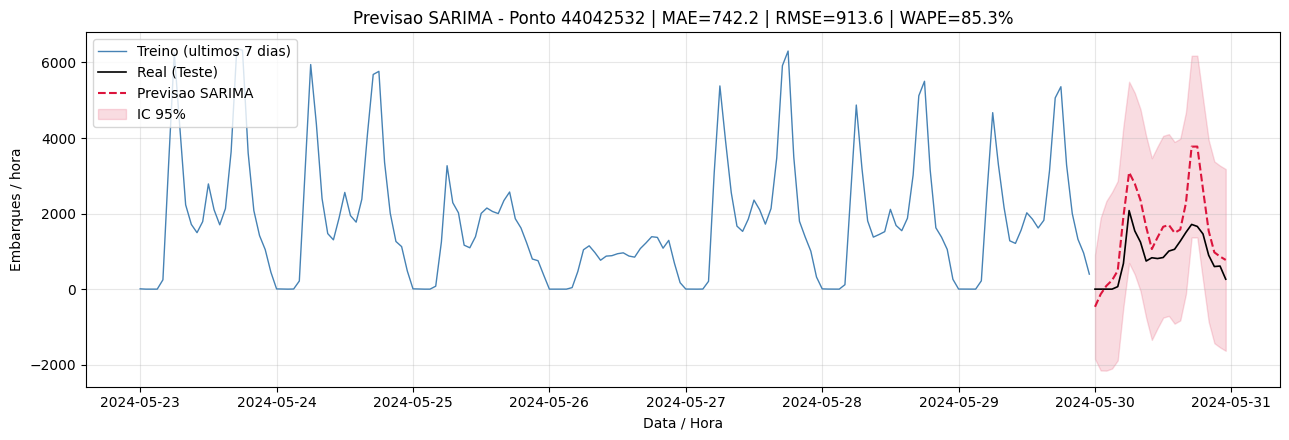

In [16]:
fc_mean, fc_ci = predict_and_evaluate(fit, test, X_test=X_test, train_data=train, stop_id=STOP_ID, output_dir=OUTPUT_DIR)